# Lab 1F-1: Classical MDM / Classical ML Retrieval Baseline

This notebook implements **Exercise 1.F, Pipeline 1**: a classical Multimedia Data Management retrieval pipeline over the Flickr8k dataset.

The purpose is not to build the strongest possible image search system. The purpose is to make the **classical pipeline explicit and inspectable**:

- structured metadata: image width, height, aspect ratio, caption count;
- semi-structured data: multiple natural-language captions per image;
- unstructured media: the image itself;
- text descriptors: TF-IDF vectors built from captions;
- visual descriptors: handcrafted HSV color histograms plus edge density;
- retrieval model: exact cosine similarity and k-NN over explicit handcrafted descriptors;
- evaluation: the same shared query file used to compare this classical pipeline with the modern pipeline handled in Notebook 2.

Important boundary: this notebook uses **classical machine learning** over explicit descriptors. The k-NN component is allowed because it retrieves over handcrafted descriptors; it does not train a representation model.


## How to read this notebook

Each major block follows the same teaching pattern:

1. **What MDM component this block represents**.
2. **What data structure is produced**.
3. **How to inspect the produced object**.
4. **How the output should be interpreted**.

Do not treat the FAST_DEV results as a final benchmark. `FAST_DEV=True` keeps the notebook quick for Colab and classroom testing while preserving the same retrieval pipeline and evaluation protocol used by the full run.


## 0. Setup

This cell defines the notebook mode and imports the libraries.

### FAST_DEV mode

`FAST_DEV=True` keeps the notebook fast enough for classroom and Colab testing. It uses a small subset of Flickr8k, but it does not change the retrieval pipeline or the evaluation protocol.

Important: FAST_DEV results are only a smoke test. They should not be reported as final retrieval performance. For final evaluation, set `FAST_DEV=False` and run on the full dataset.

`FAST_DEV_LIMIT = 200` sets the target subset size. The subset must include all reference images required by image/fused evaluation queries, then it fills the remaining slots with ordinary dataset examples.

`K_VALUES = [1, 5, 10, 20, 50]` defines the cutoffs used for Precision@K and Recall@K. For example, Precision@10 asks: among the first 10 retrieved images, how many are relevant?


In [1]:
FAST_DEV = True
FAST_DEV_LIMIT = 200
K_VALUES = [1, 5, 10, 20, 50]

from pathlib import Path
import hashlib
import json
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import ImageFilter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors

try:
    import cv2
except ImportError:
    cv2 = None

LAB_DIR = Path('content/lab/1F')
if not (LAB_DIR / 'evaluation_queries.json').exists():
    LAB_DIR = Path('.')
OUTPUT_DIR = LAB_DIR / 'outputs'
FIGURE_DIR = OUTPUT_DIR / 'figures'
QUERY_FILE = LAB_DIR / 'evaluation_queries.json'

with QUERY_FILE.open("r", encoding="utf-8") as f:
    evaluation_queries = json.load(f)

reference_image_ids = {
    q["reference_image_id"]
    for q in evaluation_queries
    if q.get("reference_image_id")
    and {"image", "fused"} & set(q.get("query_modes", []))
}

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f'FAST_DEV={FAST_DEV}')
print(f"Evaluation protocol contains {len(evaluation_queries)} queries.")
print(f"Image/fused queries require {len(reference_image_ids)} reference images.")


FAST_DEV=True
Evaluation protocol contains 8 queries.
Image/fused queries require 6 reference images.


### Optional Colab dependency note

In Colab, some packages may already be installed. If the import cell above fails because `datasets` or `cv2` is missing, install the missing package and then rerun the setup cell.

The notebook does not install packages automatically because repeated installations make classroom runs slower and less reproducible.


In [ ]:
# Uncomment only if Colab reports missing packages.
# !pip -q install datasets scikit-learn opencv-python


## 1. Offline ingestion path: loading Flickr8k

This block corresponds to the **multimedia source ingestion** stage of the Part E architecture.

Flickr8k is a small image-caption dataset: each image is associated with multiple human-written captions. That makes it suitable for this exercise because the same collection supports:

- text retrieval: search captions with a text query;
- visual retrieval: search images using low-level image descriptors;
- fused retrieval: combine text and visual evidence.

In this classical pipeline, the image and its captions are transformed into explicit, interpretable descriptors.


In [2]:
from datasets import load_dataset, concatenate_datasets

print('Loading Flickr8k...')
ds = load_dataset('jxie/flickr8k')
full_ds = concatenate_datasets([ds['train'], ds['test']])
print(f'Total Flickr8k images loaded before FAST_DEV selection: {len(full_ds)}')


Loading Flickr8k...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/687 [00:00<?, ?B/s]

data/train-00000-of-00002-2f8f6bfa852eac(…):   0%|          | 0.00/414M [00:00<?, ?B/s]

data/train-00001-of-00002-2173151d8cd6c7(…):   0%|          | 0.00/414M [00:00<?, ?B/s]

...

data/test-00000-of-00001-42a2661d12c73e4(…):   0%|          | 0.00/137M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Total Flickr8k images loaded before FAST_DEV selection: 7000


### Inspect the raw dataset object

Before creating descriptors, students should inspect what the dataset actually contains. This is important in MDM: the data model must come before the retrieval model.

The cell below prints the dataset splits, shows the keys available in one item, displays one image, and prints its captions.


In [3]:
def caption_list(item):
    """Return all non-empty captions attached to one Flickr8k item."""
    caps = item.get("caption", [])
    if isinstance(caps, str):
        caps = [caps]
    elif not caps:
        caps = [item.get(f"caption_{i}", "") for i in range(5)]

    cleaned = []
    for c in caps:
        if isinstance(c, dict):
            c = c.get("raw") or c.get("text") or ""
        s = str(c).strip()
        if s:
            cleaned.append(s)
    return cleaned

Dataset splits: ['train', 'validation', 'test']
train: 6000 items
validation: 1000 items
test: 1000 items

Keys in one raw item: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4']
Sample image type: <class 'PIL.Image.Image'>
Sample image size: (500, 399)

Sample captions:
1. A black dog is running after a white dog in the snow .
2. Black dog chasing brown dog through snow
3. Two dogs chase each other across the snowy ground .
4. Two dogs play together in the snow .
5. Two dogs running through a low lying body of water .


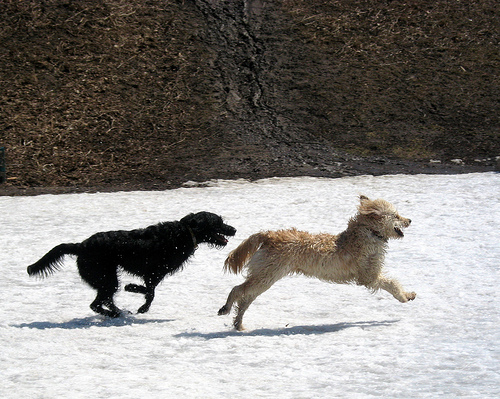

In [4]:
print("Dataset splits:", list(ds.keys()))
for split_name, split in ds.items():
    print(f"{split_name}: {len(split)} items")

sample_item = full_ds[0]
print("\nKeys in one raw item:", list(sample_item.keys()))

sample_image = sample_item["image"].convert("RGB")
print("Sample image type:", type(sample_image))
print("Sample image size:", sample_image.size)

print("\nSample captions:")
for i, caption in enumerate(caption_list(sample_item), start=1):
    print(f"{i}. {caption}")

display(sample_image)


### Convert raw items into an MDM table

The next cell builds a dataframe called `df`. This dataframe is not the final feature database. It is an intermediate representation that makes the collection easier to inspect.

The table separates the three data categories required by the exercise:

- **structured fields**: `width`, `height`, `aspect_ratio`, `caption_count`;
- **semi-structured fields**: the list of captions;
- **unstructured object**: the image itself, kept in the Hugging Face dataset and referenced by `dataset_pos`.

The generated `image_id` is a stable identifier used by the retrieval and evaluation code.


In [5]:
def normalize_text(text):
    return re.sub(r'[^a-z0-9]+', ' ', str(text).lower()).strip()


def caption_list(item):
    caps = item.get('caption', [])
    if isinstance(caps, str):
        caps = [caps]
    elif not caps:
        caps = [item.get(f'caption_{i}', '') for i in range(5)]
    cleaned = []
    for c in caps:
        if isinstance(c, dict):
            c = c.get('raw') or c.get('text') or ''
        s = str(c).strip()
        if s:
            cleaned.append(s)
    return cleaned


def stable_image_id(item, idx, image):
    for key in ('image_id', 'img_id', 'filename', 'file_name'):
        value = item.get(key)
        if value:
            return Path(str(value)).name
    filename = getattr(image, 'filename', '')
    if filename:
        return Path(filename).name
    captions = caption_list(item)
    first_caption = captions[0] if captions else ''
    w, h = image.size
    digest = hashlib.sha1(f'{first_caption}|{w}x{h}'.encode('utf-8')).hexdigest()[:12]
    return f'flickr8k_{digest}'


records = []
for idx in range(len(full_ds)):
    item = full_ds[idx]
    image = item['image'].convert('RGB')
    w, h = image.size
    captions = caption_list(item)
    records.append({
        'image_id': stable_image_id(item, idx, image),
        'dataset_pos': idx,
        'width': w,
        'height': h,
        'aspect_ratio': round(w / h, 4),
        'caption_count': len(captions),
        'captions': captions,
        'all_captions': ' '.join(captions),
    })

df = pd.DataFrame(records)
dup_count = int(df['image_id'].duplicated().sum())
if dup_count:
    warnings.warn(f'Found {dup_count} duplicate image rows; keeping first occurrence per image_id.')
    df = df.drop_duplicates(subset='image_id', keep='first').reset_index(drop=True)

if FAST_DEV:
    reference_df = df[df["image_id"].isin(reference_image_ids)].copy()
    remaining_df = df[~df["image_id"].isin(reference_image_ids)].copy()

    if len(reference_df) < len(reference_image_ids):
        missing_refs = sorted(reference_image_ids - set(reference_df["image_id"]))
        raise ValueError(
            "FAST_DEV cannot run because some required reference images are missing from the dataset: "
            f"{missing_refs}. Fix evaluation_queries.json or run with FAST_DEV=False."
        )

    if len(reference_df) > FAST_DEV_LIMIT:
        raise ValueError(
            f"FAST_DEV_LIMIT={FAST_DEV_LIMIT} is smaller than the number of required reference images "
            f"({len(reference_df)}). Increase FAST_DEV_LIMIT."
        )

    n_remaining = max(0, FAST_DEV_LIMIT - len(reference_df))

    df = pd.concat(
        [reference_df, remaining_df.head(n_remaining)],
        ignore_index=True,
    )

    print("FAST_DEV is active.")
    print(f"Subset size: {len(df)} images.")
    print(f"Required reference images included: {len(reference_df)} / {len(reference_image_ids)}.")
else:
    print(f"FULL mode is active. Dataset size: {len(df)} images.")

image_id_to_pos = dict(zip(df['image_id'], df['dataset_pos']))

fast_dev_summary = pd.DataFrame([
    {
        "mode": "FAST_DEV" if FAST_DEV else "FULL",
        "indexed_images": len(df),
        "evaluation_queries": len(evaluation_queries),
        "required_reference_images": len(reference_image_ids),
        "reference_images_present": len(reference_image_ids & set(df["image_id"])),
    }
])

display(fast_dev_summary)

signature = {
    'fast_dev': FAST_DEV,
    'count': int(len(df)),
    'first_items': df[['image_id', 'width', 'height', 'captions']].head(5).to_dict(orient='records'),
}
signature_path = OUTPUT_DIR / ('dataset_signature_fast_dev.json' if FAST_DEV else 'dataset_signature_full.json')
if signature_path.exists():
    old_signature = json.loads(signature_path.read_text(encoding='utf-8'))
    if old_signature.get('first_items') != signature['first_items']:
        warnings.warn(f'Dataset signature changed: {signature_path}')
signature_path.write_text(json.dumps(signature, indent=2), encoding='utf-8')
df.head()


FAST_DEV is active.
Subset size: 200 images.
Required reference images included: 6 / 6.


,mode,indexed_images,evaluation_queries,required_reference_images,reference_images_present
0,FAST_DEV,200,8,6,6


,image_id,dataset_pos,width,height,aspect_ratio,caption_count,captions,all_captions
0,flickr8k_7d574f378a10,80,500,250,2.0000,5,[A group of people surf on a very large wave ....,A group of people surf on a very large wave . ...
1,flickr8k_4d8a66384cfc,109,381,500,0.7620,5,[A black dog and a brown dog with a yellow foa...,A black dog and a brown dog with a yellow foam...
2,flickr8k_7b25162904de,112,333,500,0.6660,5,[A big black dog bares its teeth while running...,A big black dog bares its teeth while running ...
3,flickr8k_399f77d75708,146,500,377,1.3263,5,[A man in all black is using a green bike to t...,A man in all black is using a green bike to tr...
4,flickr8k_a54193a03087,1021,500,334,1.4970,5,[Four children are playing on a hill of sand ....,Four children are playing on a hill of sand . ...


### FAST_DEV subset sanity check

The table above is a sanity check. In FAST_DEV, the subset is small, but it must still contain the reference images needed by image/fused queries. Otherwise image and fused retrieval would not be testing the same protocol as the full run.


### How to read the dataframe output

Each row corresponds to one image. The `captions` column contains the human-written descriptions for that image. The `all_captions` column merges those captions into one text field so that TF-IDF can treat each image as one retrievable document.

In this exercise, an image is retrieved as the final object, but captions are used as textual descriptors for that image.


In [6]:
print("Number of indexed images:", len(df))
print("Columns:", list(df.columns))

display(df[["image_id", "dataset_pos", "width", "height", "aspect_ratio", "caption_count"]].head(10))

caption_preview = []
for _, row in df.head(3).iterrows():
    for i, caption in enumerate(row["captions"], start=1):
        caption_preview.append({
            "image_id": row["image_id"],
            "caption_number": i,
            "caption": caption,
        })

display(pd.DataFrame(caption_preview))


Number of indexed images: 200
Columns: ['image_id', 'dataset_pos', 'width', 'height', 'aspect_ratio', 'caption_count', 'captions', 'all_captions']


,image_id,dataset_pos,width,height,aspect_ratio,caption_count
0,flickr8k_7d574f378a10,80,500,250,2.0000,5
1,flickr8k_4d8a66384cfc,109,381,500,0.7620,5
2,flickr8k_7b25162904de,112,333,500,0.6660,5
3,flickr8k_399f77d75708,146,500,377,1.3263,5
4,flickr8k_a54193a03087,1021,500,334,1.4970,5
5,flickr8k_aa924126bebf,2331,345,500,0.6900,5
6,flickr8k_b804321b8004,0,500,399,1.2531,5
7,flickr8k_513af9616c0f,1,300,500,0.6000,5
8,flickr8k_a5975e478c8a,2,500,333,1.5015,5
9,flickr8k_21145dc611d9,3,500,360,1.3889,5


,image_id,caption_number,caption
0,flickr8k_7d574f378a10,1,A group of people surf on a very large wave .
1,flickr8k_7d574f378a10,2,a group of surfers catching a wave
2,flickr8k_7d574f378a10,3,People surfing and attempting to surf in the o...
3,flickr8k_7d574f378a10,4,Several people are surfing on a wave in the sea .
4,flickr8k_7d574f378a10,5,Surfers on a huge ocean wave at sunset .
5,flickr8k_4d8a66384cfc,1,A black dog and a brown dog with a yellow foam...
6,flickr8k_4d8a66384cfc,2,A brown dog and a black dog playing with a yel...
7,flickr8k_4d8a66384cfc,3,"Two dogs on a lawn play with a plastic toy , i..."
8,flickr8k_4d8a66384cfc,4,"Two dogs , one brown one black with a yellow t..."
9,flickr8k_4d8a66384cfc,5,Two dogs run to catch a yellow soccer ball .


## 2. Part E architecture mapping

The code must remain aligned with the fixed Part E architecture. The mapping below explains where each notebook object belongs.

The key point is that **feature extraction and retrieval are separate stages**. The notebook first extracts descriptors offline, stores them in matrices, and then uses those matrices during online query processing.


### Code-to-architecture mapping table

Use this mapping to connect the notebook implementation to the fixed Part E software architecture.

| Code artifact | Fixed Part E architecture component |
|---|---|
| dataset loading | multimedia sources |
| dataframe columns such as width, height, aspect ratio, caption count | structured store |
| Flickr8k caption lists | semi-structured store |
| image files/PIL images | media/content DB |
| TF-IDF fitting over captions | offline text descriptor extraction |
| HSV histogram and edge-density extraction | offline visual descriptor extraction |
| Canny edge detection | optional nested visual low-level sub-step, not a top-level architecture module |
| `tfidf_matrix` and `visual_matrix` | feature/descriptor DB |
| transforming a text query | online reuse of the text descriptor extractor |
| extracting features from query image | online reuse of the visual descriptor extractor |
| k-NN index/search over handcrafted descriptors | query processor/query engine; classical instance-based retrieval |
| cosine similarity, ranking, and late score fusion | query processor/query engine |
| result grids and P@K/R@K plots | results/visualization |

The important discipline is architectural: visualization is not a separate external module; it belongs to the result/visualization component of the query engine path.


## 3. Offline text descriptor extraction: TF-IDF

This block builds the text side of the feature/descriptor database.

TF-IDF means **term frequency–inverse document frequency**. It represents each image by the words and short word pairs that appear in its captions. Frequent but uninformative English words are removed. Terms that are frequent in one image's captions but not common everywhere receive higher weight.

In MDM terms:

- input: caption text from the semi-structured store;
- extraction: TF-IDF vectorization;
- output: `tfidf_matrix`, a document-term matrix used for text retrieval.


In [7]:
def rank_scores(scores, exclude_image_id=None, top_k=10):
    ranked = np.argsort(scores)[::-1]
    results = []
    for idx in ranked:
        image_id = df.iloc[int(idx)]['image_id']
        if exclude_image_id is not None and image_id == exclude_image_id:
            continue
        results.append({'image_id': image_id, 'score': float(scores[int(idx)]), 'rank': len(results) + 1})
        if len(results) >= top_k:
            break
    return results


tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2), sublinear_tf=True)
tfidf_matrix = tfidf.fit_transform(df['all_captions'])
print(f'tfidf_matrix shape: {tfidf_matrix.shape}')


def rank_text_only(query_text, exclude_image_id=None, top_k=10):
    query_vec = tfidf.transform([query_text])
    scores = cosine_similarity(query_vec, tfidf_matrix).ravel()
    return rank_scores(scores, exclude_image_id=exclude_image_id, top_k=top_k)

tfidf_matrix shape: (200, 5000)


### How to read the TF-IDF output

`tfidf_matrix shape: (N, M)` means:

- `N` = number of indexed images in this run;
- `M` = number of selected terms or bigrams.

With `FAST_DEV=True`, `N` should be at most `FAST_DEV_LIMIT` and should include every required reference image for image/fused queries. The number of terms may be capped by `max_features=5000`.



In [8]:
feature_names = np.array(tfidf.get_feature_names_out())
print("Number of TF-IDF features:", len(feature_names))
print("First 30 vocabulary terms:")
print(feature_names[:30])

row_index = 0
row = tfidf_matrix[row_index].tocoo()
top_positions = np.argsort(row.data)[::-1][:10]

top_terms = pd.DataFrame({
    "image_id": [df.iloc[row_index]["image_id"]] * len(top_positions),
    "term": feature_names[row.col[top_positions]],
    "tfidf_weight": row.data[top_positions],
})

print("\nTop TF-IDF terms for the first image:")
display(top_terms)
print("\nCaptions for the same image:")
for caption in df.iloc[row_index]["captions"]:
    print("-", caption)


Number of TF-IDF features: 5000
First 30 vocabulary terms:
['adult' 'adult sitting' 'adults' 'adults bench' 'adults child'
 'adults dressed' 'adults look' 'adults stand' 'adults wearing'
 'adults work' 'advertisement' 'advertisement asian' 'advertisement woman'
 'advertising' 'advertising driving' 'aerial' 'air' 'air green'
 'air night' 'air snowy' 'airborne' 'american' 'animals' 'appears' 'area'
 'arm' 'arm floats' 'arms' 'arms air' 'arts']

Top TF-IDF terms for the first image:


,image_id,term,tfidf_weight
0,flickr8k_7d574f378a10,wave,0.367108
1,flickr8k_7d574f378a10,people surfing,0.256756
2,flickr8k_7d574f378a10,wave people,0.256756
3,flickr8k_7d574f378a10,surfing,0.256756
4,flickr8k_7d574f378a10,surfers,0.256756
5,flickr8k_7d574f378a10,surf,0.238200
6,flickr8k_7d574f378a10,ocean,0.187920
7,flickr8k_7d574f378a10,people,0.157526
8,flickr8k_7d574f378a10,group,0.156197
9,flickr8k_7d574f378a10,catching wave,0.151644



Captions for the same image:
- A group of people surf on a very large wave .
- a group of surfers catching a wave
- People surfing and attempting to surf in the ocean on a big wave .
- Several people are surfing on a wave in the sea .
- Surfers on a huge ocean wave at sunset .


### Text-only query example

This cell shows the actual ranked list returned by the classical text pipeline for one simple query. The score is cosine similarity between the query TF-IDF vector and each image-caption TF-IDF vector.


In [9]:
demo_text_query = "a dog playing in the snow"
text_demo_results = rank_text_only(demo_text_query, top_k=5)

display(pd.DataFrame(text_demo_results))

for result in text_demo_results[:3]:
    row = df[df["image_id"] == result["image_id"]].iloc[0]
    print(f"\nRank {result['rank']} | score={result['score']:.4f} | image_id={result['image_id']}")
    for caption in row["captions"][:2]:
        print("-", caption)


,image_id,score,rank
0,flickr8k_93461360ba58,0.377604,1
1,flickr8k_e65743e7fda5,0.318938,2
2,flickr8k_7b25162904de,0.169935,3
3,flickr8k_81de01d1b91a,0.167355,4
4,flickr8k_7f0e9552c834,0.166760,5



Rank 1 | score=0.3776 | image_id=flickr8k_93461360ba58
- Two children and a black dog are playing out in the snow .
- Two children and a dog play in the snow with a woods behind them .

Rank 2 | score=0.3189 | image_id=flickr8k_e65743e7fda5
- A dog in a snowy area .
- A spotted dog catching a ball on a snowy field .

Rank 3 | score=0.1699 | image_id=flickr8k_7b25162904de
- A big black dog bares its teeth while running through the snow .
- A black dog is running through the snow .


## 4. Offline visual descriptor extraction: HSV histogram + edge density

This block builds the visual side of the feature/descriptor database.

The visual representation is deliberately handcrafted:

- **HSV histogram**: summarizes the distribution of hue, saturation, and brightness values in the image;
- **edge density**: measures how many edge pixels are detected, giving a rough indication of visual structure or texture.

This is a classical MDM representation. It is interpretable, cheap, and deterministic, but it is also semantically weak. It can match images with similar colors or edge patterns even when the objects are different.


In [10]:
def extract_hsv_histogram(image, bins=(8, 8, 8)):
    image = image.convert('RGB').resize((224, 224))
    if cv2 is not None:
        arr = np.asarray(image)
        hsv = cv2.cvtColor(arr, cv2.COLOR_RGB2HSV)
        hist = cv2.calcHist([hsv], [0, 1, 2], None, bins, [0, 180, 0, 256, 0, 256]).astype('float32').ravel()
    else:
        hsv = image.convert('HSV')
        arr = np.asarray(hsv)
        hist, _ = np.histogramdd(arr.reshape(-1, 3), bins=bins, range=((0, 255), (0, 255), (0, 255)))
        hist = hist.astype('float32').ravel()
    norm = np.linalg.norm(hist)
    return hist / norm if norm else hist


def extract_edge_density(image):
    gray = image.convert('L').resize((224, 224))
    if cv2 is not None:
        edges = cv2.Canny(np.asarray(gray), 100, 200)
        density = float(np.mean(edges > 0))
    else:
        edges = gray.filter(ImageFilter.FIND_EDGES)
        density = float(np.mean(np.asarray(edges) > 32))
    return np.array([density], dtype='float32')


def extract_visual_descriptor(image):
    return np.concatenate([extract_hsv_histogram(image), extract_edge_density(image)]).astype('float32')


visual_matrix = np.vstack([extract_visual_descriptor(full_ds[int(pos)]['image']) for pos in df['dataset_pos']])
visual_matrix = visual_matrix / np.maximum(np.linalg.norm(visual_matrix, axis=1, keepdims=True), 1e-12)
print(f'visual_matrix shape: {visual_matrix.shape}')

# Classical instance-based retrieval over explicit handcrafted descriptors.
# This is k-NN over HSV histogram + edge-density features, not representation learning.
visual_knn = NearestNeighbors(n_neighbors=min(len(df), max(K_VALUES) + 1), metric='cosine', algorithm='brute')
visual_knn.fit(visual_matrix)


def visual_knn_scores(query_image):
    query_vec = extract_visual_descriptor(query_image).reshape(1, -1)
    query_vec = query_vec / np.maximum(np.linalg.norm(query_vec, axis=1, keepdims=True), 1e-12)
    distances, indices = visual_knn.kneighbors(query_vec, n_neighbors=len(df), return_distance=True)
    scores = np.full(len(df), -np.inf, dtype='float32')
    scores[indices[0]] = 1.0 - distances[0]
    return scores


def rank_visual_knn(query_image, exclude_image_id=None, top_k=10):
    scores = visual_knn_scores(query_image)
    return rank_scores(scores, exclude_image_id=exclude_image_id, top_k=top_k)


def rank_fused(query_text, query_image, text_weight=0.5, exclude_image_id=None, top_k=10):
    if query_text is None or query_image is None:
        raise ValueError('Fused retrieval requires both query_text and query_image.')
    text_scores = cosine_similarity(tfidf.transform([query_text]), tfidf_matrix).ravel()
    visual_scores = visual_knn_scores(query_image)
    scores = text_weight * text_scores + (1.0 - text_weight) * visual_scores
    return rank_scores(scores, exclude_image_id=exclude_image_id, top_k=top_k)

visual_matrix shape: (200, 513)


### How to read the visual descriptor output

`visual_matrix shape: (N, 513)` means:

- `N` = number of indexed images;
- `512` dimensions come from the HSV histogram with `8 × 8 × 8` bins;
- `1` dimension comes from edge density;
- total = `512 + 1 = 513`.

The k-NN model is fitted over this matrix. It is a classical instance-based retrieval method: it stores the feature vectors and returns the nearest vectors at query time.


Visual matrix shape: (200, 513)
Expected descriptor length: 8*8*8 + 1 = 513


,image_id,edge_density_feature_after_normalization,descriptor_l2_norm
0,flickr8k_7d574f378a10,0.111877,1.0
1,flickr8k_4d8a66384cfc,0.155991,1.0
2,flickr8k_7b25162904de,0.032588,1.0
3,flickr8k_399f77d75708,0.150568,1.0
4,flickr8k_a54193a03087,0.158525,1.0
5,flickr8k_aa924126bebf,0.189579,1.0
6,flickr8k_b804321b8004,0.098019,1.0
7,flickr8k_513af9616c0f,0.138210,1.0
8,flickr8k_a5975e478c8a,0.039768,1.0
9,flickr8k_21145dc611d9,0.129559,1.0


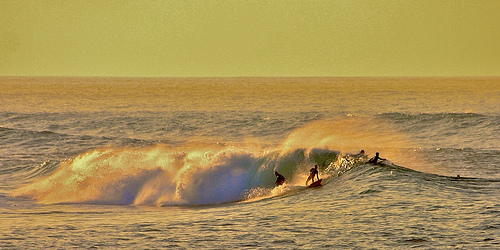

Raw descriptor length: 513
Raw edge density before final L2 normalization: 0.1125837042927742


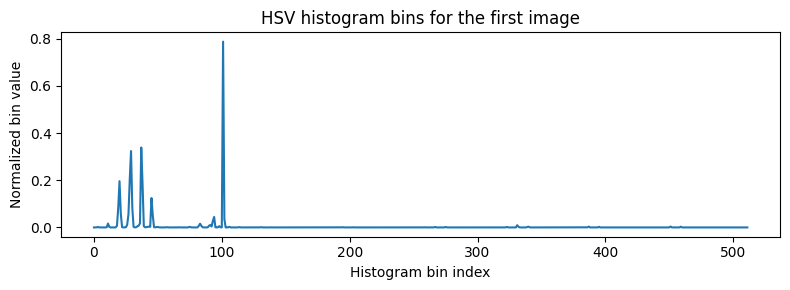

In [11]:
print("Visual matrix shape:", visual_matrix.shape)
print("Expected descriptor length: 8*8*8 + 1 =", 8 * 8 * 8 + 1)

descriptor_preview = pd.DataFrame({
    "image_id": df["image_id"].head(10),
    "edge_density_feature_after_normalization": visual_matrix[:10, -1],
    "descriptor_l2_norm": np.linalg.norm(visual_matrix[:10], axis=1),
})

display(descriptor_preview)

demo_image = full_ds[int(df.iloc[0]["dataset_pos"])]["image"].convert("RGB")
display(demo_image)

demo_descriptor = extract_visual_descriptor(demo_image)
print("Raw descriptor length:", len(demo_descriptor))
print("Raw edge density before final L2 normalization:", float(demo_descriptor[-1]))

plt.figure(figsize=(8, 3))
plt.plot(demo_descriptor[:-1])
plt.title("HSV histogram bins for the first image")
plt.xlabel("Histogram bin index")
plt.ylabel("Normalized bin value")
plt.tight_layout()
plt.show()


### Visual-only query example

This example uses one image as the query and retrieves images with similar handcrafted visual descriptors. It excludes the query image itself from the result list, because retrieving the same image would be trivial and would inflate the evaluation.


In [12]:
demo_query_image = full_ds[int(df.iloc[0]["dataset_pos"])]["image"].convert("RGB")
demo_query_id = df.iloc[0]["image_id"]

visual_demo_results = rank_visual_knn(demo_query_image, exclude_image_id=demo_query_id, top_k=5)
display(pd.DataFrame(visual_demo_results))

print("Query image_id:", demo_query_id)
print("Query captions:")
for caption in df.iloc[0]["captions"][:3]:
    print("-", caption)


,image_id,score,rank
0,flickr8k_1dbc375c0a38,0.765728,1
1,flickr8k_07213b2c75de,0.381684,2
2,flickr8k_a6953d068556,0.349338,3
3,flickr8k_f9018dfaddc1,0.344963,4
4,flickr8k_32240ce294e8,0.334961,5


Query image_id: flickr8k_7d574f378a10
Query captions:
- A group of people surf on a very large wave .
- a group of surfers catching a wave
- People surfing and attempting to surf in the ocean on a big wave .


## 5. Shared evaluation queries

The file `evaluation_queries.json` defines a small shared evaluation protocol for Pipeline 1 and Pipeline 2.

We use this separate JSON file for three reasons:

1. **Same task for both pipelines**: the classical pipeline and the modern pipeline must be evaluated on the same queries.
2. **Reproducibility**: queries are not hidden inside code cells; they can be inspected, edited, and version-controlled.
3. **Separation of retrieval from labels**: the system retrieves results, but the relevant set is defined externally by query rules and optional manual labels.

In this notebook, caption-match labels are computed from transparent caption keyword rules plus optional manually listed image IDs. This is a teaching protocol, not a fully human-labeled benchmark.


### Fields in `evaluation_queries.json`

Each query object contains:

- `query_id`: stable name of the evaluation query;
- `query_text`: natural-language query used for text retrieval;
- `reference_image_id`: intended image-query identifier for image/fused retrieval;
- `required_terms`: caption terms that define automatic relevant-set membership;
- `optional_terms`: extra terms useful for human interpretation but not required by the automatic rule;
- `query_modes`: which retrieval modes should use this query: `text`, `image`, and/or `fused`;
- `manual_relevant_image_ids`: optional manually curated relevant images.

In the current file, the manual lists are empty, so the notebook derives the relevant set from required caption terms.


### Inspect and validate the evaluation query file

This cell loads `content/lab/1F/evaluation_queries.json`, the shared evaluation protocol used by both Pipeline 1 and Pipeline 2. The file contains the query text, required terms, optional terms, query modes, reference image IDs, and optional manual label lists. Keeping these queries in one JSON file ensures the two notebooks are compared on the same retrieval tasks.

This cell validates that the shared query protocol can be executed with the current indexed dataset. Text queries use only the query text. Image and fused queries also require a valid reference image from the indexed collection.

If validation fails, that is a data-preparation problem, not a retrieval problem: update `evaluation_queries.json` or construct `FAST_DEV` so it includes all required reference images.



In [13]:
def term_in_caption(term, caption):
    return normalize_text(term) in normalize_text(caption)


def captions_match_required(captions, required_terms):
    return all(
        any(term_in_caption(term, caption) for caption in captions)
        for term in required_terms
    )


def relevance_ids(query):
    relevant = set(query.get("manual_relevant_image_ids") or [])
    required_terms = query.get("required_terms") or []

    for _, row in df.iterrows():
        if captions_match_required(row["captions"], required_terms):
            relevant.add(row["image_id"])

    reference_id = query.get("reference_image_id")
    if reference_id:
        relevant.discard(reference_id)

    return relevant


def query_needs_reference_image(query):
    return bool({"image", "fused"} & set(query.get("query_modes", [])))


def reference_image_for_query(query, relevant=None):
    reference_id = query.get("reference_image_id")

    if not query_needs_reference_image(query):
        return None, None

    if reference_id and reference_id in image_id_to_pos:
        return reference_id, full_ds[int(image_id_to_pos[reference_id])]["image"]

    raise ValueError(
        f'Query {query["query_id"]} requires image/fused retrieval, '
        f'but reference_image_id={reference_id!r} is not present in the current dataset. '
        'Fix evaluation_queries.json or construct FAST_DEV so it includes all required reference images.'
    )


def queries_for_mode(mode):
    return [q for q in evaluation_queries if mode in q.get("query_modes", [])]


validation_rows = []
missing_reference_rows = []

for query in evaluation_queries:
    reference_id = query.get("reference_image_id")
    needs_reference = query_needs_reference_image(query)
    reference_present = bool(reference_id and reference_id in image_id_to_pos)

    validation_rows.append({
        "query_id": query["query_id"],
        "query_text": query["query_text"],
        "query_modes": ",".join(query.get("query_modes", [])),
        "reference_image_id": reference_id,
        "needs_reference_image": needs_reference,
        "reference_present_in_current_run": reference_present,
        "manual_relevant_count": len(query.get("manual_relevant_image_ids") or []),
        "automatic_relevant_count_in_this_run": len(relevance_ids(query)),
    })

    if needs_reference and not reference_present:
        missing_reference_rows.append({
            "query_id": query["query_id"],
            "reference_image_id": reference_id,
            "query_modes": query.get("query_modes", []),
        })

validation_df = pd.DataFrame(validation_rows)
display(validation_df)

if missing_reference_rows:
    display(pd.DataFrame(missing_reference_rows))
    raise ValueError(
        "Some image/fused queries do not have a valid reference_image_id in the current dataset subset. "
        "Do not change the protocol inside the notebook. Fix evaluation_queries.json or make FAST_DEV include "
        "the required reference images."
    )

print(f"Loaded and validated {len(evaluation_queries)} evaluation queries.")




,query_id,query_text,query_modes,reference_image_id,needs_reference_image,reference_present_in_current_run,manual_relevant_count,automatic_relevant_count_in_this_run
0,dog_snow_001,a dog playing in the snow,"text,image,fused",flickr8k_7b25162904de,True,True,0,6
1,children_beach_001,children playing on a beach,"text,image,fused",flickr8k_a54193a03087,True,True,0,0
2,man_bicycle_001,a man riding a bicycle,"text,image,fused",flickr8k_399f77d75708,True,True,0,1
3,soccer_ball_001,a soccer player kicking a ball,"text,image,fused",flickr8k_4d8a66384cfc,True,True,0,1
4,horse_field_001,a horse running in a field,"text,image,fused",flickr8k_aa924126bebf,True,True,0,0
5,surfer_wave_001,a surfer riding a wave,"text,image,fused",flickr8k_7d574f378a10,True,True,0,0
6,people_table_001,a group of people sitting at a table,text,flickr8k_cf819f0866ac,False,False,0,0
7,boy_jump_001,a boy jumping in the air,text,flickr8k_5df4aa57c242,False,False,0,6


Loaded and validated 8 evaluation queries.


### How automatic caption-match labels are computed

For each query, the function `relevance_ids(query)` scans the captions of every indexed image. An image enters the relevant set when its captions contain all `required_terms`.

Example: for `a dog playing in the snow`, the required terms are `dog` and `snow`. An image is relevant if at least one of its captions contains `dog` and at least one of its captions contains `snow`.

This rule is intentionally simple and inspectable. Its weakness is also clear: it is lexical. It can miss synonyms and can mark shallow keyword matches as relevant.


## 6. Evaluation paths: text-only, visual-only, fused

The notebook evaluates three retrieval modes separately.

- **Text-only**: query text → TF-IDF vector → cosine similarity against caption vectors.
- **Visual-only**: query image → handcrafted visual descriptor → k-NN search.
- **Fused**: text score and visual score are combined by weighted late fusion.

The fused path is used only for queries whose `query_modes` include both text and image evidence. This avoids pretending that text-only queries have an image component.


In [14]:
def precision_at_k(retrieved_ids, relevant, k):
    return len(set(retrieved_ids[:k]) & relevant) / k if k else 0.0


def recall_at_k(retrieved_ids, relevant, k):
    return len(set(retrieved_ids[:k]) & relevant) / len(relevant) if relevant else 0.0


def summarize_metrics(per_query):
    summary = {}
    for k in K_VALUES:
        summary[str(k)] = {
            'avg_precision': float(np.mean([row[f'p@{k}'] for row in per_query])) if per_query else 0.0,
            'avg_recall': float(np.mean([row[f'r@{k}'] for row in per_query])) if per_query else 0.0,
        }
    return summary


def evaluate_text_only(text_queries, top_k=max(K_VALUES)):
    per_query = []
    for query in text_queries:
        relevant = relevance_ids(query)
        retrieved = rank_text_only(query['query_text'], exclude_image_id=query.get('reference_image_id'), top_k=top_k)
        retrieved_ids = [row['image_id'] for row in retrieved]
        row = {'query_id': query['query_id'], 'relevant_count': len(relevant), 'retrieved_ids': retrieved_ids}
        for k in K_VALUES:
            row[f'p@{k}'] = precision_at_k(retrieved_ids, relevant, k)
            row[f'r@{k}'] = recall_at_k(retrieved_ids, relevant, k)
        per_query.append(row)
    return {'per_query': per_query, 'summary': summarize_metrics(per_query)}


def evaluate_visual_only(image_queries, top_k=max(K_VALUES)):
    per_query = []
    for query in image_queries:
        relevant = relevance_ids(query)
        reference_id, query_image = reference_image_for_query(query, relevant)
        if query_image is None:
            continue
        retrieved = rank_visual_knn(query_image, exclude_image_id=reference_id, top_k=top_k)
        retrieved_ids = [row['image_id'] for row in retrieved]
        row = {'query_id': query['query_id'], 'reference_image_id': reference_id, 'relevant_count': len(relevant), 'retrieved_ids': retrieved_ids}
        for k in K_VALUES:
            row[f'p@{k}'] = precision_at_k(retrieved_ids, relevant, k)
            row[f'r@{k}'] = recall_at_k(retrieved_ids, relevant, k)
        per_query.append(row)
    return {'per_query': per_query, 'summary': summarize_metrics(per_query)}


def evaluate_fused(dual_queries, alpha=0.5, top_k=max(K_VALUES)):
    per_query = []
    for query in dual_queries:
        relevant = relevance_ids(query)
        reference_id, query_image = reference_image_for_query(query, relevant)
        if query_image is None:
            continue
        retrieved = rank_fused(query['query_text'], query_image, text_weight=alpha, exclude_image_id=reference_id, top_k=top_k)
        retrieved_ids = [row['image_id'] for row in retrieved]
        row = {'query_id': query['query_id'], 'reference_image_id': reference_id, 'relevant_count': len(relevant), 'retrieved_ids': retrieved_ids}
        for k in K_VALUES:
            row[f'p@{k}'] = precision_at_k(retrieved_ids, relevant, k)
            row[f'r@{k}'] = recall_at_k(retrieved_ids, relevant, k)
        per_query.append(row)
    return {'per_query': per_query, 'summary': summarize_metrics(per_query)}


text_results = evaluate_text_only(queries_for_mode('text'))
visual_results = evaluate_visual_only(queries_for_mode('image'))
fused_results = evaluate_fused(queries_for_mode('fused'))

classic_results = {
    'fast_dev': FAST_DEV,
    'k_values': K_VALUES,
    'text_only': text_results,
    'visual_only': visual_results,
    'fused': fused_results,
}
print(json.dumps({mode: classic_results[mode]['summary'] for mode in ('text_only', 'visual_only', 'fused')}, indent=2))

{
  "text_only": {
    "1": {
      "avg_precision": 0.375,
      "avg_recall": 0.2708333333333333
    },
    "5": {
      "avg_precision": 0.25,
      "avg_recall": 0.4166666666666667
    },
    "10": {
      "avg_precision": 0.1625,
      "avg_recall": 0.4791666666666667
    },
    "20": {
      "avg_precision": 0.08125,
      "avg_recall": 0.4791666666666667
    },
    "50": {
      "avg_precision": 0.035,
      "avg_recall": 0.5
    }
  },
  "visual_only": {
    "1": {
      "avg_precision": 0.0,
      "avg_recall": 0.0
    },
    "5": {
      "avg_precision": 0.0,
      "avg_recall": 0.0
    },
    "10": {
      "avg_precision": 0.0,
      "avg_recall": 0.0
    },
    "20": {
      "avg_precision": 0.008333333333333333,
      "avg_recall": 0.027777777777777776
    },
    "50": {
      "avg_precision": 0.013333333333333334,
      "avg_recall": 0.25
    }
  },
  "fused": {
    "1": {
      "avg_precision": 0.16666666666666666,
      "avg_recall": 0.16666666666666666
    },
    "5": 

### How to interpret the metric output

The printed JSON reports average Precision@K and Recall@K for each mode.

- **Precision@K**: among the top K retrieved images, what fraction is relevant?
- **Recall@K**: among all relevant images in the dataset subset, what fraction was retrieved in the top K?

Expected pattern in FAST_DEV:

- text-only often performs better than handcrafted visual-only retrieval because the relevant-set rule is caption-based;
- visual-only can be weak because HSV color and edge density do not understand semantic objects such as “dog”, “soccer”, or “surfer”;
- fused retrieval may or may not improve results because weak visual evidence can dilute strong text evidence.

Do not report these FAST_DEV numbers as final results. They are a smoke test and teaching demonstration.


In [15]:
def per_query_table(result, mode_name):
    rows = []
    for row in result["per_query"]:
        rows.append({
            "mode": mode_name,
            "query_id": row["query_id"],
            "relevant_count": row["relevant_count"],
            "p@1": row.get("p@1"),
            "p@5": row.get("p@5"),
            "p@10": row.get("p@10"),
            "r@10": row.get("r@10"),
            "first_retrieved_id": row["retrieved_ids"][0] if row.get("retrieved_ids") else None,
        })
    return pd.DataFrame(rows)

display(pd.concat([
    per_query_table(text_results, "text_only"),
    per_query_table(visual_results, "visual_only"),
    per_query_table(fused_results, "fused"),
], ignore_index=True))


,mode,query_id,relevant_count,p@1,p@5,p@10,r@10,first_retrieved_id
0,text_only,dog_snow_001,6,1.0,1.0,0.6,1.000000,flickr8k_93461360ba58
1,text_only,children_beach_001,0,0.0,0.0,0.0,0.000000,flickr8k_57e223011a64
2,text_only,man_bicycle_001,1,1.0,0.2,0.1,1.000000,flickr8k_6cb0f4e1c528
3,text_only,soccer_ball_001,1,1.0,0.2,0.1,1.000000,flickr8k_c2608a9374cc
4,text_only,horse_field_001,0,0.0,0.0,0.0,0.000000,flickr8k_7ed1f672196a
5,text_only,surfer_wave_001,0,0.0,0.0,0.0,0.000000,flickr8k_c475ae60332f
6,text_only,people_table_001,0,0.0,0.0,0.0,0.000000,flickr8k_44b4ff070f88
7,text_only,boy_jump_001,6,0.0,0.6,0.5,0.833333,flickr8k_cf4c80f30e35
8,visual_only,dog_snow_001,6,0.0,0.0,0.0,0.000000,flickr8k_d0a24ad8015c
9,visual_only,children_beach_001,0,0.0,0.0,0.0,0.000000,flickr8k_02c3f26f7250


## 7. Results / visualization

This block belongs to the **results/visualization** part of the Part E architecture.

The plots summarize how average precision and recall change as K increases. Usually, Recall@K increases with larger K because the system retrieves more items. Precision@K may decrease because later results are often less relevant.


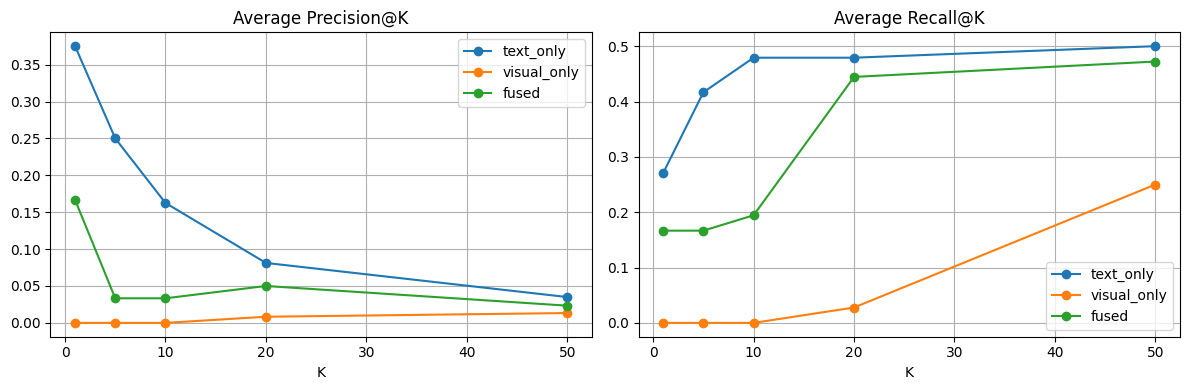

Saved results to outputs/classic_results_fast_dev.json


In [16]:
def plot_metric_summary(results_by_mode):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for mode, result in results_by_mode.items():
        axes[0].plot(K_VALUES, [result['summary'][str(k)]['avg_precision'] for k in K_VALUES], marker='o', label=mode)
        axes[1].plot(K_VALUES, [result['summary'][str(k)]['avg_recall'] for k in K_VALUES], marker='o', label=mode)
    axes[0].set_title('Average Precision@K')
    axes[1].set_title('Average Recall@K')
    for ax in axes:
        ax.set_xlabel('K')
        ax.grid(True)
        ax.legend()
    fig.tight_layout()
    return fig


fig = plot_metric_summary({'text_only': text_results, 'visual_only': visual_results, 'fused': fused_results})
if not FAST_DEV:
    fig.savefig(FIGURE_DIR / 'classic_precision_recall.png', dpi=150)
plt.show()

result_path = OUTPUT_DIR / ('classic_results_fast_dev.json' if FAST_DEV else 'classic_results_full.json')
result_path.write_text(json.dumps(classic_results, indent=2), encoding='utf-8')
print(f'Saved results to {result_path}')

### What we should conclude from this notebook?

The main conclusion is methodological, not numerical.

This notebook shows how a classical MDM system can be built from explicit components: structured metadata, caption descriptors, handcrafted visual descriptors, exact similarity, k-NN retrieval, and transparent evaluation.

Its limitations are also visible:

- TF-IDF is lexical and does not understand meaning beyond words and word pairs;
- HSV histograms and edge density capture low-level appearance, not semantic objects;
- fusion is only useful when both modalities provide reliable evidence;
- the small FAST_DEV subset is not a benchmark.

The modern notebook, Pipeline 2, should then be read as a controlled contrast: same dataset and query protocol, but learned multimodal embeddings and vector indexing replace manual descriptor engineering.
